# Импрорты и нужные классы

In [1]:
import sys
import os
import torch
import copy
import numpy as np
from dotenv import load_dotenv

sys.path.append('..')
env_file = os.path.join('..', '.env')
load_dotenv(env_file)
rowGlam_type = os.environ['ROW_GLAM_TYPE'] # custom or base

doclaynet_train_pdf_path = os.environ['DOCLAYNET_TRAIN_PDF_PATH']
doclaynet_coco_path = os.environ['DOCLAYNET_COCO_PATH']
doclaynet_test_pdf_path = os.environ['DOCLAYNET_TEST_PDF_PATH']
doclaynet_test_coco_path_for_doc = os.environ['DOCLAYNET_TEST_COCO_PATH_FOR_DOC']
#запустить скрипт doc2pub для создания coco аннотации с метками как в publaynet
doclaynet_test_coco_path_for_pub = os.environ['DOCLAYNET_TEST_COCO_PATH_FOR_PUB']
doclaynet_train_cash_pdf_path = os.environ['DOCLAYNET_TRAIN_CASH_PDF_PATH']
doclaynet_test_cash_pdf_path_for_doc = os.environ['DOCLAYNET_TEST_CASH_PDF_PATH_FOR_DOC']
doclaynet_test_cash_pdf_path_for_pub = os.environ['DOCLAYNET_TEST_CASH_PDF_PATH_FOR_PUB']

publaynet_train_pdf_path = os.environ['PUBLAYNET_TRAIN_PDF_PATH']
publaynet_coco_path = os.environ['PUBLAYNET_COCO_PATH']
publaynet_test_pdf_path = os.environ['PUBLAYNET_TEST_PDF_PATH']
publaynet_test_coco_path = os.environ['PUBLAYNET_TEST_COCO_PATH']
publaynet_train_cash_pdf_path = os.environ['PUBLAYNET_TRAIN_CASH_PDF_PATH']
publaynet_test_cash_pdf_path = os.environ['PUBLAYNET_TEST_CASH_PDF_PATH']

In [2]:
from rows2regionsGLAM.utils.pdf_manager import PDFManager
from rows2regionsGLAM.utils.loger import Loger
from rows2regionsGLAM.utils.row_manager import RowManager
from rows2regionsGLAM.utils.ploter import Ploter
from rows2regionsGLAM.utils.trainer import Trainer
from rows2regionsGLAM.utils.tester import Tester
from rows2regionsGLAM.utils.cacher import Cacher
from rows2regionsGLAM.utils.coco_manager import COCOManager
from rows2regionsGLAM.utils.imbalance import calculate_imbalance
from rows2regionsGLAM.utils.tester import collect_maps, print_map_table

from rows2regionsGLAM.models.rowGLAM_base import TorchModelBase, PARAMS_BASE
from rows2regionsGLAM.models.rowGLAM_custom import TorchModel, PARAMS

from rows2regionsGLAM.tokenizers import RowGLAMTokenizer
from rows2regionsGLAM.converters import Rows2Regions
from rows2regionsGLAM.datasetloaders.base_line_dataset import GLAMDataset
from pager.page_model.sub_models import RegionModel, RowsModel

/home/roma/work/PageR/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
loger = Loger('log.txt')
pdf_manager = PDFManager(conf={"loger": loger, "pdf_reader": "PDFMiner"})
row_manager = RowManager(conf={"loger": loger, "add_image": True})

pub_coco_manager = COCOManager(conf={"loger": loger, "coco_path": publaynet_coco_path})
doc_coco_manager = COCOManager(conf={"loger": loger, "coco_path": doclaynet_coco_path})

ploter = Ploter(conf={"loger": loger})
tokenizer = RowGLAMTokenizer()
loger(tokenizer.get_name())

pdf2torch_dict = Cacher({
    "loger": loger,
    "pdf_manager": pdf_manager,
    "row_manager": row_manager,
    "tokenizer": tokenizer
})

# PubLayNet

In [5]:
json_true_regions, PUB_CLASSES = pub_coco_manager.get_regions_from_json()

In [6]:
PUB_CLASSES[3] = "text"
PUB_CLASSES

{1: 'text', 2: 'title', 3: 'text', 4: 'table', 5: 'figure', 0: 'other'}

In [7]:
file_names = list(json_true_regions.keys())
file_names.sort()

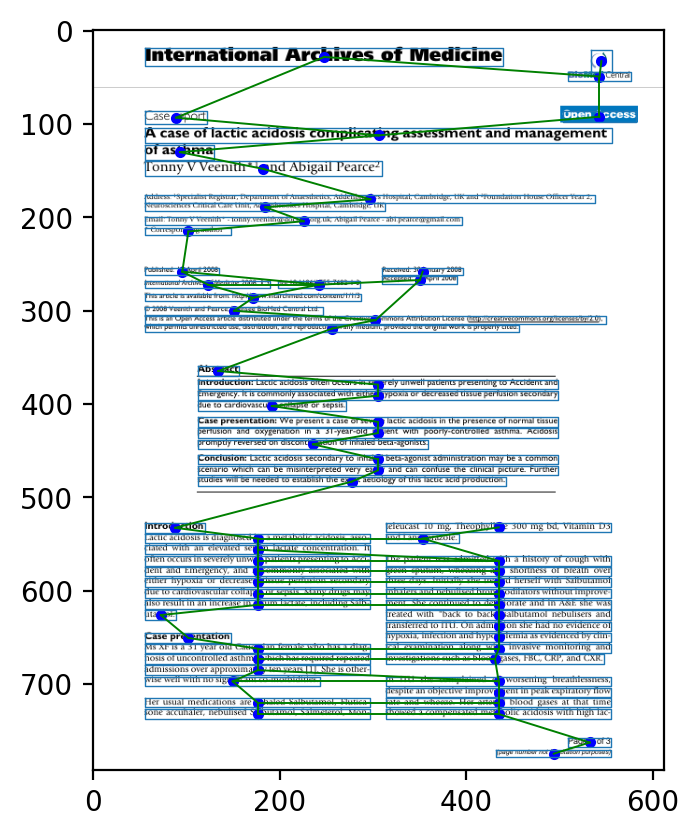

In [8]:
# отрисовка, проверка работы менеджеров
num_file = 1
file_name = file_names[num_file]
dataset_file = os.path.join(publaynet_train_pdf_path, file_name)
pdf_json, pdf_img = pdf_manager.get_json_and_img_from_pdf(dataset_file, num_page=0)
row_json = row_manager.get_row_json_from_pdf_json(pdf_json)
torch_dict = tokenizer(row_json, pdf_img)
ploter.set_dpi(200)
ploter.plot_img(pdf_img)
ploter.plot_tokens(tokenizer, torch_dict)

## Сохранение датасета

In [9]:
pub_dataset = GLAMDataset({
    "loger": loger,
    "pdf_dir": publaynet_train_pdf_path,
    "coco_file": publaynet_coco_path,
    "count_class": len(PUB_CLASSES),
    "name_dataset": "publaynet",
    "default_index": 0,
    "cache_dir": publaynet_train_cash_pdf_path,
    "pdf2torch_dict": pdf2torch_dict
})

# Создание Cache
N = len(pub_dataset)
for i, d in enumerate(pub_dataset):
    print(f"{(i+1)/N*100:4.2f} %", end='\r')

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requi

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requi

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requi

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requi

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requi

...

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requi

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)


/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requi

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requi

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)


## Отрисовска файла из датасета

Cannot set non-stroke color because 2 components are specified but only 1 (grayscale), 3 (rgb) and 4 (cmyk) are supported
Cannot set non-stroke color because 2 components are specified but only 1 (grayscale), 3 (rgb) and 4 (cmyk) are supported
Cannot set non-stroke color because 2 components are specified but only 1 (grayscale), 3 (rgb) and 4 (cmyk) are supported
Cannot set non-stroke color because 2 components are specified but only 1 (grayscale), 3 (rgb) and 4 (cmyk) are supported


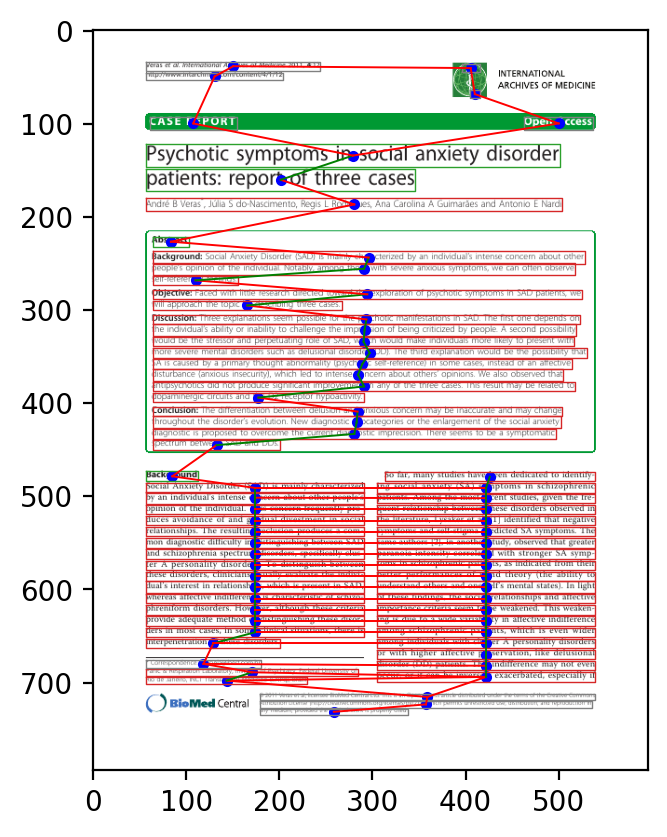

In [11]:
torch_dict_pub_train = pub_dataset[100]
path_pdf = os.path.join(publaynet_train_pdf_path, torch_dict_pub_train['file_name'] + ".pdf")
_, img = pdf_manager.get_json_and_img_from_pdf(path_pdf)
ploter.set_dpi(200)
ploter.plot_img(img)
ploter.plot_tokens(tokenizer, torch_dict_pub_train, markup=True)

## Параметры модели

In [16]:
PUB_GLAM_MODEL = 'pub_row2region_GLAM_artic'
if rowGlam_type == "base":
    PUB_PARAMS = copy.deepcopy(PARAMS_BASE)
elif rowGlam_type == "custom":
    PUB_PARAMS = copy.deepcopy(PARAMS)
    
PUB_PARAMS["NodeClasses"] = len(PUB_CLASSES)

PUB_PARAMS["epochs"] = 10
PUB_PARAMS["batch_size"] = 64

if rowGlam_type == "custom":
    PUB_PARAMS["model_type"] = 2 # 1 or 2 or 3

In [17]:
# Дисбаланс классов ------------------------------------
publaynet_imbalance, edge_imbalance = calculate_imbalance(pub_dataset)

print(publaynet_imbalance, edge_imbalance)

PUB_PARAMS['loss_params']['publaynet_imbalance'] = publaynet_imbalance
PUB_PARAMS['loss_params']['edge_imbalance'] = edge_imbalance

PUB_PARAMS

[0.03282150253653526, 0.004089109133929014, 0.1997614949941635, 0.6161039471626282, 0.004932202398777008, 0.14229173958301544] 0.3404429852962494


{'node_featch': 15,
 'edge_featch': 4,
 'epochs': 10,
 'batch_size': 64,
 'learning_rate': 0.001,
 'model_type': 2,
 'concat_gcn': True,
 'mlp_pred': [{'in': -1, 'batch_norm': True, 'activation': 'gelu', 'out': 256},
  {'in': -1, 'batch_norm': True, 'activation': 'gelu', 'out': 256},
  {'in': -1, 'batch_norm': True, 'activation': 'gelu', 'out': 128}],
 'gcn_node': [{'linear_in': -1,
   'batch_norm': True,
   'activation': 'gelu',
   'aggregation': 'tag',
   'K': 3,
   'linear_out': 256,
   'size': 128},
  {'linear_in': -1,
   'batch_norm': True,
   'activation': 'gelu',
   'K': 3,
   'aggregation': 'tag',
   'linear_out': 256,
   'size': 64}],
 'mlp_node_class': [{'in': -1,
   'batch_norm': True,
   'activation': 'gelu',
   'out': 256},
  {'in': -1, 'batch_norm': True, 'activation': 'gelu', 'out': 128},
  {'in': -1, 'batch_norm': True, 'activation': 'softmax', 'out': 6}],
 'mlp_node_post': None,
 'gcn_node_post': [{'linear_in': -1,
   'batch_norm': True,
   'activation': 'gelu',
   'ag

## Обучение модели

In [18]:
# model:torch.nn.Module = TorchModel(PUB_PARAMS)
# total_params = sum(p.numel() for p in model.parameters())  
# print(f"Number of parameters: {total_params}") 

In [50]:
trainer_pub = Trainer(conf={"loger": loger, "params": PUB_PARAMS, "model_name": PUB_GLAM_MODEL})
trainer_pub.start_train(5, pub_dataset)


            DATASET INFO:
            count row: 1000
            first: dict_keys(['N', 'X', 'Y', 'inds', 'true_edges', 'true_nodes', 'sp_A', 'file_name'])
            	 A:torch.Size([83, 83])
            	 nodes_feature:torch.Size([83, 15])
            	 edges_feature:torch.Size([114, 4])
            	 true_edges:torch.Size([114])
            end:dict_keys(['N', 'X', 'Y', 'inds', 'true_edges', 'true_nodes', 'sp_A', 'file_name'])
            	 A:torch.Size([154, 154])
            	 nodes_feature:torch.Size([154, 15])
            	 edges_feature:torch.Size([242, 4])
            	 true_edges:torch.Size([242])
        node_featch:	15
edge_featch:	4
epochs:	10
batch_size:	64
learning_rate:	0.001
model_type:	2
concat_gcn:	True
mlp_pred:	[{'in': -1, 'batch_norm': True, 'activation': 'gelu', 'out': 256}, {'in': -1, 'batch_norm': True, 'activation': 'gelu', 'out': 256}, {'in': -1, 'batch_norm': True, 'activation': 'gelu', 'out': 128}]
gcn_node:	[{'linear_in': -1, 'batch_norm': True, 'activat

KeyboardInterrupt: 

# DocLayNet

In [4]:
json_true_regions, DOC_CLASSES = doc_coco_manager.get_regions_from_json()

In [5]:
# DOC_CLASSES[3] = "text"
DOC_CLASSES

{1: 'Caption',
 2: 'Footnote',
 3: 'Formula',
 4: 'List-item',
 5: 'Page-footer',
 6: 'Page-header',
 7: 'Picture',
 8: 'Section-header',
 9: 'Table',
 10: 'Text',
 11: 'Title',
 0: 'other'}

In [6]:
file_names = list(json_true_regions.keys())
file_names.sort()

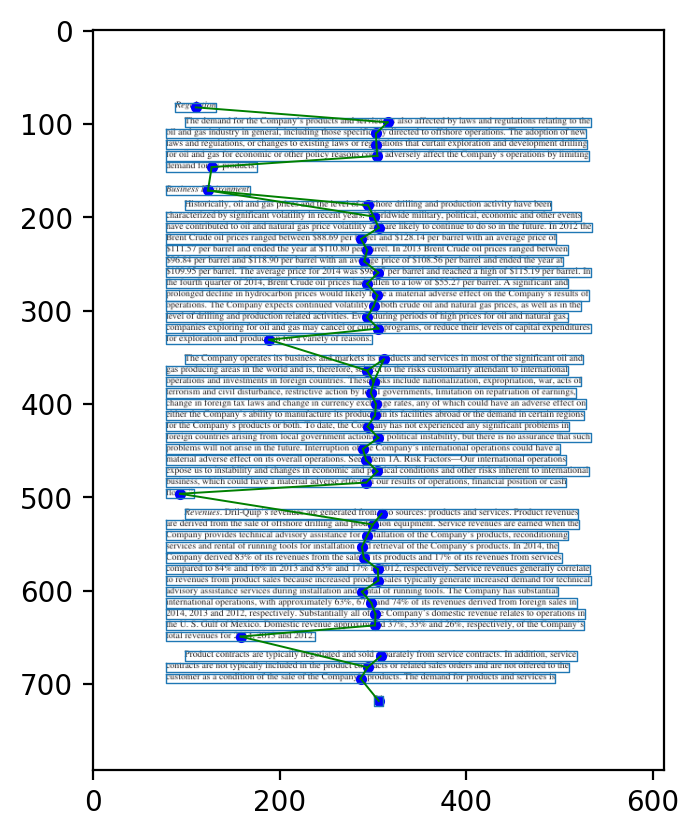

In [7]:
# отрисовка, проверка работы менеджеров
num_file = 1
file_name = file_names[num_file]
dataset_file = os.path.join(doclaynet_train_pdf_path, file_name)
pdf_json, pdf_img = pdf_manager.get_json_and_img_from_pdf(dataset_file, num_page=0)
row_json = row_manager.get_row_json_from_pdf_json(pdf_json)
torch_dict = tokenizer(row_json, pdf_img)
ploter.set_dpi(200)
ploter.plot_img(pdf_img)
ploter.plot_tokens(tokenizer, torch_dict)

## Сохранение датасета

In [8]:
doc_dataset = GLAMDataset({
    "loger": loger,
    "pdf_dir": doclaynet_train_pdf_path,
    "coco_file": doclaynet_coco_path,
    "count_class": len(DOC_CLASSES),
    "name_dataset": "doclaynet",
    "default_index": 0,
    "cache_dir": doclaynet_train_cash_pdf_path,
    "pdf2torch_dict": pdf2torch_dict
})

# Создание Cache
N = len(doc_dataset)
for i, d in enumerate(doc_dataset):
    print(f"{(i+1)/N*100:4.2f} %", end='\r')

## Отрисовска файла из датасета

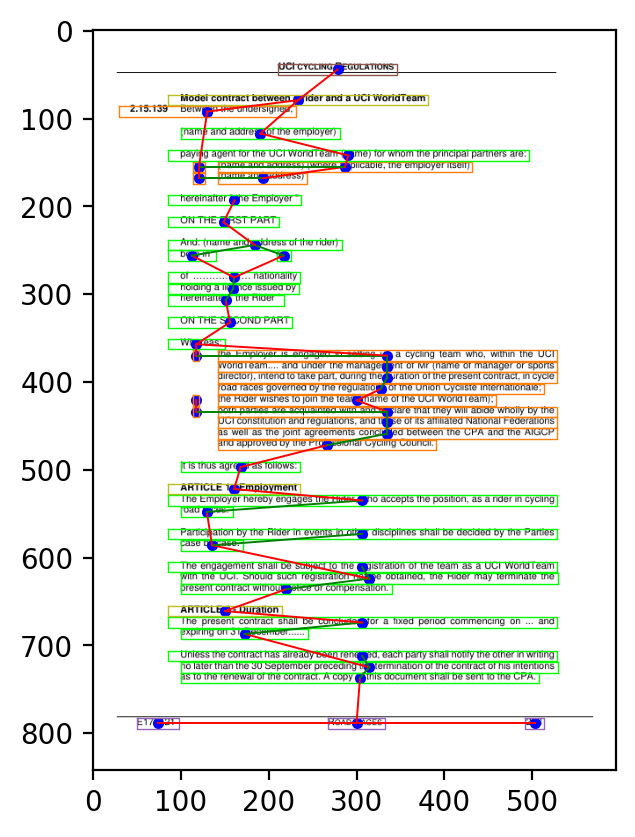

In [9]:
torch_dict_doc_train = doc_dataset[100]
path_pdf = os.path.join(doclaynet_train_pdf_path, torch_dict_doc_train['file_name'] + ".pdf")
_, img = pdf_manager.get_json_and_img_from_pdf(path_pdf)
ploter.set_dpi(200)
ploter.plot_img(img)
ploter.plot_tokens(tokenizer, torch_dict_doc_train, markup=True)

## Параметры модели

In [10]:

DOC_GLAM_MODEL = 'doc_row2region_GLAM_artic'
if rowGlam_type == "base":
    DOC_PARAMS = copy.deepcopy(PARAMS_BASE)
elif rowGlam_type == "custom":
    DOC_PARAMS = copy.deepcopy(PARAMS)
    
DOC_PARAMS["NodeClasses"] = len(DOC_CLASSES)

DOC_PARAMS["epochs"] = 10
DOC_PARAMS["batch_size"] = 64

if rowGlam_type == "custom":
    DOC_PARAMS["mlp_node_class"][-1]["out"] = len(DOC_CLASSES)
    DOC_PARAMS["model_type"] = 2 # 1 or 2 or 3

In [11]:
# Дисбаланс классов ------------------------------------
publaynet_imbalance, edge_imbalance = calculate_imbalance(doc_dataset)

print(publaynet_imbalance, edge_imbalance)

DOC_PARAMS['loss_params']['publaynet_imbalance'] = publaynet_imbalance
DOC_PARAMS['loss_params']['edge_imbalance'] = edge_imbalance

DOC_PARAMS

[0.04741529002785683, 0.041622597724199295, 0.3388707935810089, 0.008313455618917942, 0.006718710996210575, 0.03867875784635544, 0.01985083892941475, 0.010257160291075706, 0.01953178457915783, 0.0011361881624907255, 0.0008971018251031637, 0.4667072892189026] 0.33899925127045066


{'node_featch': 15,
 'edge_featch': 4,
 'epochs': 10,
 'batch_size': 64,
 'learning_rate': 0.001,
 'Tag': [{'in': -1, 'size': 512, 'out': 512, 'k': 3},
  {'in': 512, 'size': 256, 'out': 256, 'k': 3}],
 'NodeLinear': [-1, 64, 32],
 'NodeLinearClassifier': [-1, 16, 8],
 'EdgeLinear': [-1, 16, 4],
 'batchNormNode': True,
 'batchNormEdge': True,
 'seg_k': 0.5,
 'loss_params': {'edge_coef': 0.8,
  'node_coef': 0.2,
  'publaynet_imbalance': [0.04741529002785683,
   0.041622597724199295,
   0.3388707935810089,
   0.008313455618917942,
   0.006718710996210575,
   0.03867875784635544,
   0.01985083892941475,
   0.010257160291075706,
   0.01953178457915783,
   0.0011361881624907255,
   0.0008971018251031637,
   0.4667072892189026],
  'edge_imbalance': 0.33899925127045066},
 'sigmoidEdge': False,
 'NodeClasses': 12}

## Обучение модели

In [12]:
# model:torch.nn.Module = TorchModel(PUB_PARAMS)
# total_params = sum(p.numel() for p in model.parameters())  
# print(f"Number of parameters: {total_params}") 

In [13]:
trainer_doc = Trainer(conf={"loger": loger, "params": DOC_PARAMS, "model_name": DOC_GLAM_MODEL})
trainer_doc.start_train(5, doc_dataset)


            DATASET INFO:
            count row: 1000
            first: dict_keys(['N', 'X', 'Y', 'inds', 'true_edges', 'true_nodes', 'sp_A', 'file_name'])
            	 A:torch.Size([18, 18])
            	 nodes_feature:torch.Size([18, 15])
            	 edges_feature:torch.Size([17, 4])
            	 true_edges:torch.Size([17])
            end:dict_keys(['N', 'X', 'Y', 'inds', 'true_edges', 'true_nodes', 'sp_A', 'file_name'])
            	 A:torch.Size([117, 117])
            	 nodes_feature:torch.Size([117, 15])
            	 edges_feature:torch.Size([164, 4])
            	 true_edges:torch.Size([164])
        node_featch:	15
edge_featch:	4
epochs:	10
batch_size:	64
learning_rate:	0.001
Tag:	[{'in': -1, 'size': 512, 'out': 512, 'k': 3}, {'in': 512, 'size': 256, 'out': 256, 'k': 3}]
NodeLinear:	[-1, 64, 32]
NodeLinearClassifier:	[-1, 16, 8]
EdgeLinear:	[-1, 16, 4]
batchNormNode:	True
batchNormEdge:	True
seg_k:	0.5
loss_params:	{'edge_coef': 0.8, 'node_coef': 0.2, 'publaynet_imbalan

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/utils/_spmm.py:71: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  src = src.to_sparse_csr()
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Expected more than 1 value per channel when training, got input size torch.Size([1, 15])
(0,)
(1, 15)
Expected more than 1 value per channel when training, got input size torch.Size([1, 15])
(0,)
(1, 15)
Expected more than 1 value per channel when training, got input size torch.Size([1, 15])
(0,)
(1, 15)
Время обучения batch'а 0.36 сек                                   
Expected more than 1 value per channel when training, got input size torch.Size([1, 15])
(0,)
(1, 15)
Expected more than 1 value per channel when training, got input size torch.Size([1, 15])
(0,)
(1, 15)
Expected more than 1 value per channel when training, got input size torch.Size([1, 15])
(0,)
(1, 15)
Expected more than 1 value per channel when training, got input size torch.Size([1, 15])
(0,)
(1, 15)
Expected more than 1 value per channel when training, got input size torch.Size([1, 15])
(0,)
(1, 15)
Expected more than 1 value per channel when training, got input size torch.Size([1, 98])
(1, 4)
(2, 15)
Expected more

# Проверка работы модели PubLayNet

In [30]:
PUB_PARAMS['sigmoidEdge'] = True

if rowGlam_type == "base":
    model_pub = TorchModelBase(PUB_PARAMS)
elif rowGlam_type == "custom":
    model_pub = TorchModel(PUB_PARAMS)

model_pub.load_state_dict(torch.load(PUB_GLAM_MODEL, weights_only=True))

rows_model = RowsModel()
region_model = RegionModel()
rows2regions_pub = Rows2Regions({
    'model':model_pub, 
    'tokenizer': RowGLAMTokenizer(),
    'is_merge_extract': True,
    'classes': PUB_CLASSES
})

Cannot set non-stroke color because 2 components are specified but only 1 (grayscale), 3 (rgb) and 4 (cmyk) are supported
Cannot set non-stroke color because 2 components are specified but only 1 (grayscale), 3 (rgb) and 4 (cmyk) are supported
Cannot set non-stroke color because 2 components are specified but only 1 (grayscale), 3 (rgb) and 4 (cmyk) are supported
Cannot set non-stroke color because 2 components are specified but only 1 (grayscale), 3 (rgb) and 4 (cmyk) are supported
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the ca

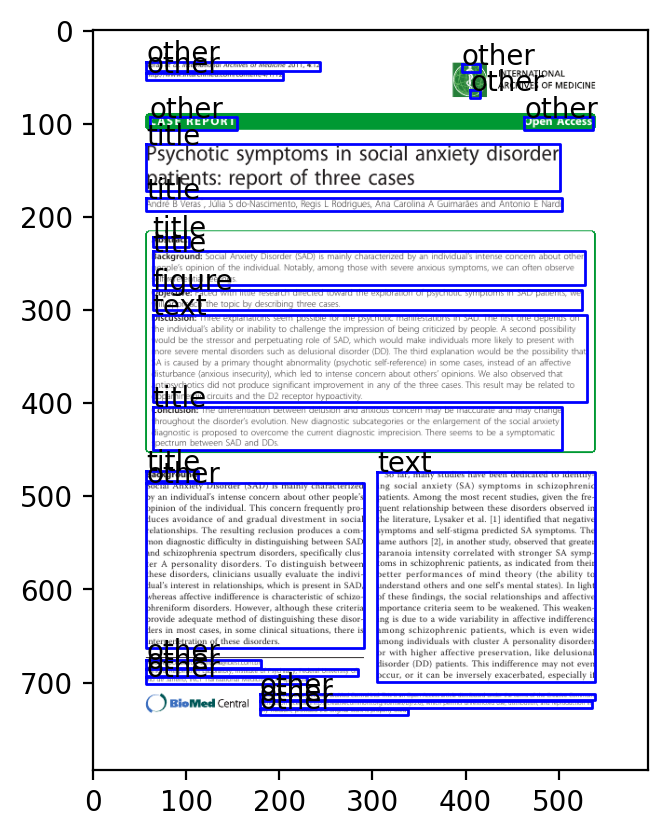

In [31]:
torch_dict_pub_train = pub_dataset[100]
path_pdf = os.path.join(publaynet_train_pdf_path, torch_dict_pub_train['file_name'] + ".pdf")
pdf_json, img = pdf_manager.get_json_and_img_from_pdf(path_pdf)
ploter.set_dpi(200)
ploter.plot_img(img)
# ploter.plot_tokens(tokenizer, torch_dict_pub_train)

# Регионы --------------------------------------------------------------
row_json = row_manager.get_row_json_from_pdf_json(pdf_json)

rows_model.from_dict({"rows": row_json})
rows2regions_pub.convert(rows_model, region_model, img)

for reg in region_model.regions:
    reg.segment.plot(text=reg.label)

# Проверка работы модели DocLayNet

In [32]:
DOC_PARAMS['sigmoidEdge'] = True

if rowGlam_type == "base":
    model_doc = TorchModelBase(DOC_PARAMS)
elif rowGlam_type == "custom":
    model_doc = TorchModel(DOC_PARAMS)

model_doc.load_state_dict(torch.load(DOC_GLAM_MODEL, weights_only=True))

rows_model = RowsModel()
region_model = RegionModel()
rows2regions_doc = Rows2Regions({
    'model':model_doc, 
    'tokenizer': RowGLAMTokenizer(),
    'is_merge_extract': True,
    'classes': DOC_CLASSES
})

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


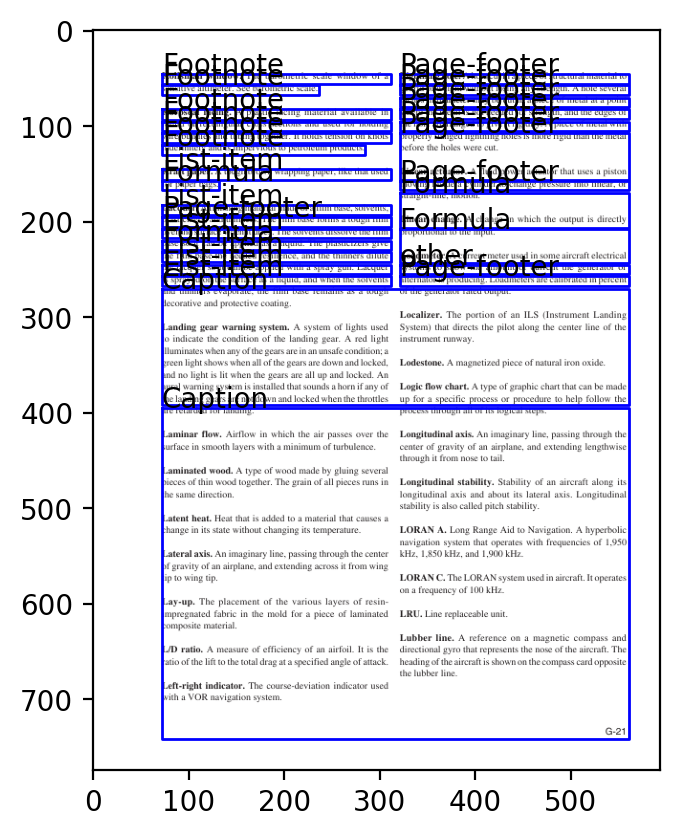

In [36]:
torch_dict_doc_train = doc_dataset[13]
path_pdf = os.path.join(doclaynet_train_pdf_path, torch_dict_doc_train['file_name'] + ".pdf")
pdf_json, img = pdf_manager.get_json_and_img_from_pdf(path_pdf)
ploter.set_dpi(200)
ploter.plot_img(img)
# ploter.plot_tokens(tokenizer, torch_dict_doc_train)

# Регионы --------------------------------------------------------------
row_json = row_manager.get_row_json_from_pdf_json(pdf_json)

rows_model.from_dict({"rows": row_json})
rows2regions_doc.convert(rows_model, region_model, img)

for reg in region_model.regions:
    reg.segment.plot(text=reg.label)

# Тестирование 

## Создание тестовых датасетов

### publaynet test dataset 

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repe

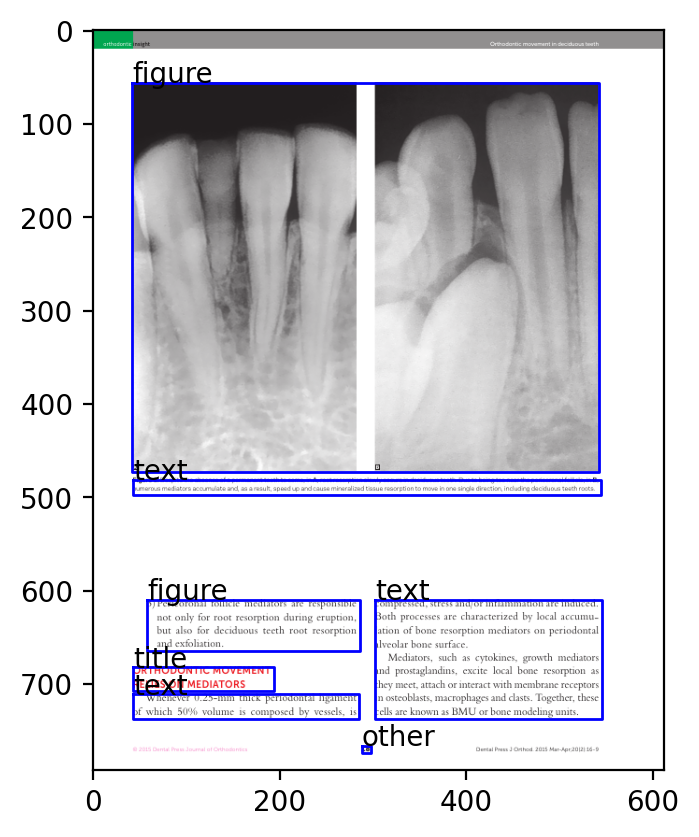

In [37]:
pub_test_dataset = GLAMDataset(
    {
    "loger": loger,
    "pdf_dir": publaynet_test_pdf_path,
    "coco_file": publaynet_test_coco_path,
    "count_class": len(PUB_CLASSES),
    "name_dataset": "publaynet",
    "default_index": 0,
    "cache_dir": publaynet_test_cash_pdf_path,
    "pdf2torch_dict": pdf2torch_dict
    }
)

torch_dict2 = pub_test_dataset[100]
path_pdf = os.path.join(publaynet_test_pdf_path, torch_dict2['file_name'] + ".pdf")
pdf_json, img = pdf_manager.get_json_and_img_from_pdf(path_pdf)
ploter.set_dpi(200)
ploter.plot_img(img)
# ploter.plot_tokens(tokenizer, torch_dict2)

# Регионы --------------------------------------------------------------
row_json = row_manager.get_row_json_from_pdf_json(pdf_json)

rows_model.from_dict({"rows": row_json})
rows2regions_pub.convert(rows_model, region_model, img)

for reg in region_model.regions:
    reg.segment.plot(text=reg.label)

In [38]:
loger("Start Test")
loger.time_log()

N = len(pub_test_dataset)
for i, d in enumerate(pub_test_dataset):
    print(f"{(i+1)/N*100:4.2f} %", end='\r')

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requi

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requi

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)


/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requi

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requi

...

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requi

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requi

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requi

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requi

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)


### doclaynet test dataset for doclaynet

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repe

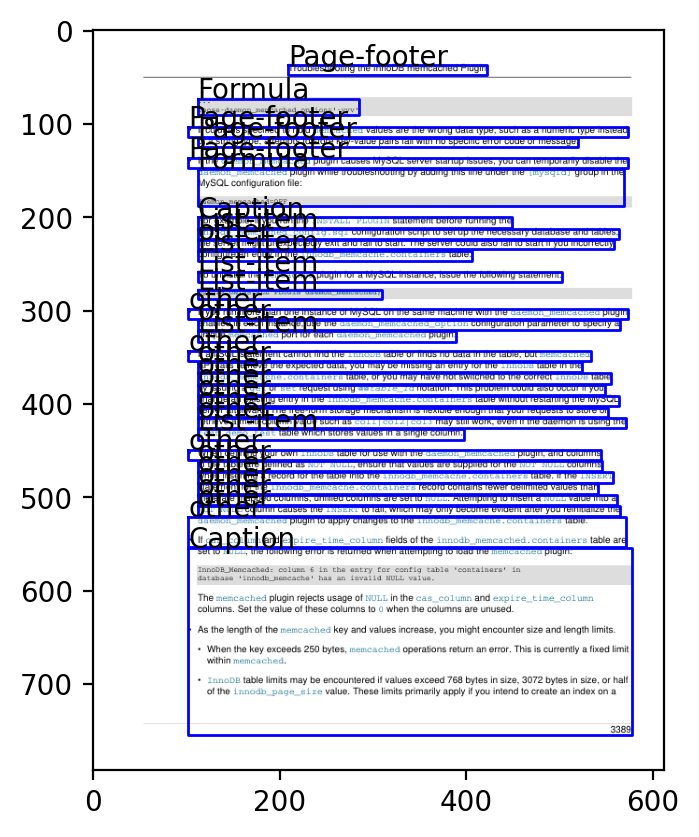

In [39]:
doc_test_dataset_for_doc = GLAMDataset(
    {
    "loger": loger,
    "pdf_dir": doclaynet_test_pdf_path,
    "coco_file": doclaynet_test_coco_path_for_doc,
    "count_class": len(DOC_CLASSES),
    "name_dataset": "doclaynet",
    "default_index": 0,
    "cache_dir": doclaynet_test_cash_pdf_path_for_doc,
    "pdf2torch_dict": pdf2torch_dict
    }
)

torch_dict2 = doc_test_dataset_for_doc[50]
path_pdf = os.path.join(doclaynet_test_pdf_path, torch_dict2['file_name'] + ".pdf")
pdf_json, img = pdf_manager.get_json_and_img_from_pdf(path_pdf)
ploter.set_dpi(200)
ploter.plot_img(img)
# ploter.plot_tokens(tokenizer, torch_dict2)

# Регионы --------------------------------------------------------------
row_json = row_manager.get_row_json_from_pdf_json(pdf_json)

rows_model.from_dict({"rows": row_json})
rows2regions_doc.convert(rows_model, region_model, img)

for reg in region_model.regions:
    reg.segment.plot(text=reg.label)

In [40]:
loger("Start Test")
loger.time_log()

N = len(doc_test_dataset_for_doc)
for i, d in enumerate(doc_test_dataset_for_doc):
    print(f"{(i+1)/N*100:4.2f} %", end='\r')

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requi

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)


/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)


/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)


/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requi

...

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requi

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requi

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requi

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requi

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)


### doclaynet test dataset for publaynet

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repe

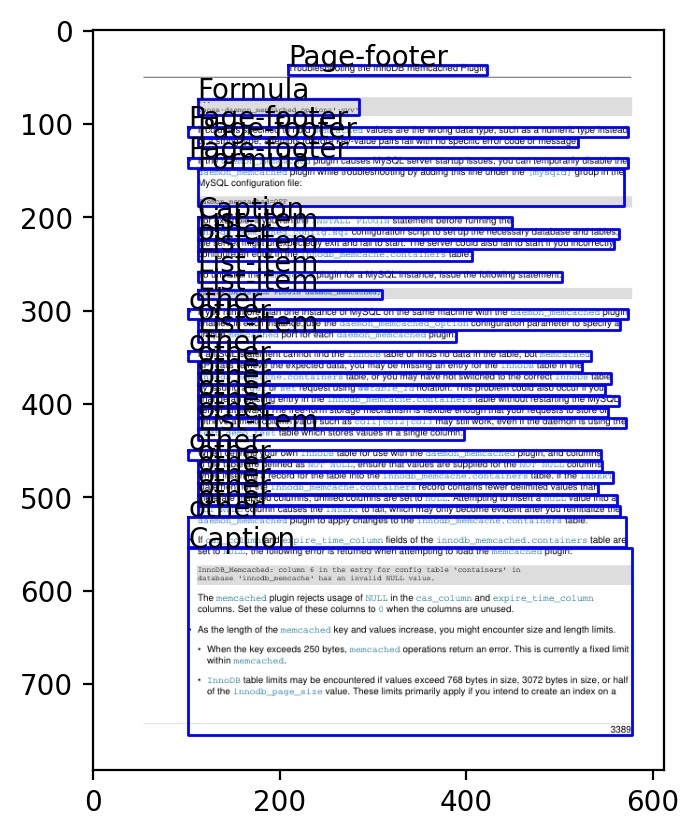

In [41]:
doc_test_dataset_for_pub = GLAMDataset(
    {
    "loger": loger,
    "pdf_dir": doclaynet_test_pdf_path,
    "coco_file": doclaynet_test_coco_path_for_pub,
    "count_class": len(DOC_CLASSES),
    "name_dataset": "doclaynet",
    "default_index": 0,
    "cache_dir": doclaynet_test_cash_pdf_path_for_pub,
    "pdf2torch_dict": pdf2torch_dict
    }
)

torch_dict2 = doc_test_dataset_for_pub[50]
path_pdf = os.path.join(doclaynet_test_pdf_path, torch_dict2['file_name'] + ".pdf")
pdf_json, img = pdf_manager.get_json_and_img_from_pdf(path_pdf)
ploter.set_dpi(200)
ploter.plot_img(img)
# ploter.plot_tokens(tokenizer, torch_dict2)

# Регионы --------------------------------------------------------------
row_json = row_manager.get_row_json_from_pdf_json(pdf_json)

rows_model.from_dict({"rows": row_json})
rows2regions_doc.convert(rows_model, region_model, img)

for reg in region_model.regions:
    reg.segment.plot(text=reg.label)

In [42]:
loger("Start Test")
loger.time_log()

N = len(doc_test_dataset_for_pub)
for i, d in enumerate(doc_test_dataset_for_pub):
    print(f"{(i+1)/N*100:4.2f} %", end='\r')

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requi

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)


/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requi

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requi

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requi

...

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)


/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requi

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requi

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requi

/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['X'] = torch.tensor(data['X'], dtype=torch.float32)
/home/roma/work/rows2regionsGLAM/notebooks/../rows2regionsGLAM/datasetloaders/base_line_dataset/GLAM_dataset.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data['Y'] = torch.tensor(data['Y'], dtype=torch.float32)


## Оценка

In [43]:
loger_train_pub_test_pub = Loger('log_train_pub_test_pub.txt')
loger_train_pub_test_doc = Loger('log_train_pub_test_doc.txt')
loger_train_doc_test_doc = Loger('log_train_doc_test_doc.txt')
loger_train_doc_test_pub = Loger('log_train_doc_test_pub.txt')

### Train pub Test pub

In [44]:
tester_train_pub_test_pub = Tester(conf={
    "loger": loger_train_pub_test_pub, 
    "pdf_manager": pdf_manager, 
    "row_manager": row_manager, 
    "rows_model": rows_model, 
    "region_model": region_model, 
    "rows2regions": rows2regions_pub})

metrics_pp = tester_train_pub_test_pub.calculate_target_and_preds(
    pub_test_dataset, 
    "publaynet", 
    "publaynet", 
    publaynet_train_pdf_path, 
    publaynet_test_pdf_path
)

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules

...

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


### Train pub Test doc

In [45]:
tester_train_pub_test_doc = Tester(conf={
    "loger": loger_train_pub_test_doc, 
    "pdf_manager": pdf_manager, 
    "row_manager": row_manager, 
    "rows_model": rows_model, 
    "region_model": region_model, 
    "rows2regions": rows2regions_pub})

metrics_pd = tester_train_pub_test_doc.calculate_target_and_preds(
    doc_test_dataset_for_pub, 
    "publaynet", 
    "doclaynet", 
    publaynet_train_pdf_path, 
    doclaynet_test_pdf_path
)

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules

...

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


### Train doc Test doc

In [46]:
tester_train_doc_test_doc = Tester(conf={
    "loger": loger_train_doc_test_doc, 
    "pdf_manager": pdf_manager, 
    "row_manager": row_manager, 
    "rows_model": rows_model, 
    "region_model": region_model, 
    "rows2regions": rows2regions_doc})

metrics_dd = tester_train_doc_test_doc.calculate_target_and_preds(
    doc_test_dataset_for_doc, 
    "doclaynet", 
    "doclaynet", 
    doclaynet_train_pdf_path, 
    doclaynet_test_pdf_path
)

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


...

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


### Train doc Test pub

In [47]:
tester_train_doc_test_pub = Tester(conf={
    "loger": loger_train_doc_test_pub, 
    "pdf_manager": pdf_manager, 
    "row_manager": row_manager, 
    "rows_model": rows_model, 
    "region_model": region_model, 
    "rows2regions": rows2regions_doc})

metrics_dp = tester_train_doc_test_pub.calculate_target_and_preds(
    pub_test_dataset, 
    "doclaynet", 
    "publaynet", 
    doclaynet_train_pdf_path, 
    publaynet_test_pdf_path
)

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules

...

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules

/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch_geometric/nn/conv/tag_conv.py:102: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
/home/roma/work/PageR/env/lib/python3.12/site-packages/torch/nn/modules

### Вывод результатов

In [48]:
print("train_pub_test_pub")
tester_train_pub_test_pub.print_result(metrics_pp)

print("train_pub_test_doc")
tester_train_pub_test_doc.print_result(metrics_pd)

print("train_doc_test_doc")
tester_train_doc_test_doc.print_result(metrics_dd)

print("train_doc_test_pub")
tester_train_doc_test_pub.print_result(metrics_dp)

/home/roma/work/PageR/env/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


train_pub_test_pub
mAP@IoU[0.50:0.95]   :0.22940429
threshold_05--------------------
precision_row       :0.6515
recall_row          :0.6607
f1_row              :0.6561
precision_word      :0.6322
recall_word         :0.6405
f1_word             :0.6363
threshold_95--------------------
precision_row       :0.4891
recall_row          :0.4832
f1_row              :0.4862
precision_word      :0.4674
recall_word         :0.4592
f1_word             :0.4633

train_pub_test_doc
mAP@IoU[0.50:0.95]   :0.16283168
threshold_05--------------------
precision_row       :0.6691
recall_row          :0.5301
f1_row              :0.5915
precision_word      :0.6750
recall_word         :0.5344
f1_word             :0.5966
threshold_95--------------------
precision_row       :0.5512
recall_row          :0.4286
f1_row              :0.4822
precision_word      :0.5252
recall_word         :0.4122
f1_word             :0.4619

train_doc_test_doc
mAP@IoU[0.50:0.95]   :0.00481724
threshold_05--------------------
preci

In [49]:
log_directory = "./"

table = collect_maps(log_directory)
print_map_table(table)

test\train   | PubLayNet  | DocLayNet 
--------------------------------------
PubLayNet    | 0.229404   | 0.000754  
DocLayNet    | 0.162832   | 0.004817  


In [ ]:
mAP@IoU[0.50:0.95]   :0.52044123
==================================================
threshold_05--------------------
precision_row       :0.8745
recall_row          :0.7442
f1_row              :0.8041
precision_word      :0.8312
recall_word         :0.7130
f1_word             :0.7676
threshold_95--------------------
precision_row       :0.7275
recall_row          :0.6222
f1_row              :0.6707
precision_word      :0.6884
recall_word         :0.5949
f1_word             :0.6382